In [14]:
# Ga naar: https://rijkswaterstaatdata.nl/waterdata/#hf1666c4e-b766-49e0-af37-c1b95f8f56e1
# Lees: 1. Haal de catalogus met beschikbare gegevens op

# Object maken 
import requests
import pandas as pd
import json

catalogus_url = "https://waterwebservices.rijkswaterstaat.nl/METADATASERVICES_DBO/OphalenCatalogus"
catalogus_body = {"CatalogusFilter": {"Compartimenten":True, "Grootheden":True}}

data = requests.post(catalogus_url, json=catalogus_body)
response = data.json()

#response.keys()
#response["LocatieLijst"]

In [4]:
# 1. Bekijk de kaart: https://waterinfo.rws.nl/publiek/waterhoogte
# 2. Zoek: Roompot buiten (SVKO)

# 3. check het response
#response.keys()
#response["LocatieLijst"][0]

plaatsen = []
for plaats in response["LocatieLijst"]:
    if "Roompot buiten (SVKO)" in plaats["Naam"]:
        plaatsen.append(plaats)
        
df_plaatsen = pd.DataFrame(plaatsen)
df_plaatsen = df_plaatsen[["Naam", "Code", "X", "Y"]]
df_plaatsen

,Naam,Code,X,Y
0,Roompot buiten (SVKO),RPBU,547077.385000,5.718883e+06
1,Roompot buiten (SVKO),RPBU,547224.950585,5.718947e+06


In [5]:
# Toont de eigenlijke waarde
df_plaatsen.iloc[0]

Naam    Roompot buiten (SVKO)
Code                     RPBU
X                  547077.385
Y                 5718882.685
Name: 0, dtype: object

In [6]:
# Ga naar: https://rijkswaterstaatdata.nl/waterdata/#hf1666c4e-b766-49e0-af37-c1b95f8f56e1
# Lees: 4. Haal gekozen waarnemingen op

import pandas as pd
import requests
import json

rmp_url = "https://waterwebservices.rijkswaterstaat.nl/ONLINEWAARNEMINGENSERVICES_DBO/OphalenWaarnemingen"
rmp_body = {
    "Locatie":{
        "Code":"RPBU", "X":547077.385, "Y":5718882.685},
        "AquoPlusWaarnemingMetadata":{"AquoMetadata":{"Compartiment":{"Code":"OW"}, "Grootheid":{"Code":"WATHTE"}}},
    "Periode":{
        "Begindatumtijd":"2025-10-22T14:00:00.000+01:00",
        "Einddatumtijd":"2025-10-24T16:00:00.000+01:00"}}

response = requests.post(rmp_url, json=rmp_body)
roompot = response.json()
# print(roompot["WaarnemingenLijst"][0]["MetingenLijst"][0].items())


data = []
for waarneming in roompot["WaarnemingenLijst"]:
    for meting in waarneming["MetingenLijst"]:
        data.append({
            "tijd": meting["Tijdstip"],
            "waarde": meting["Meetwaarde"]["Waarde_Numeriek"],
            })

df = pd.DataFrame(data)
df["tijd"] = pd.to_datetime(df["tijd"])
df.head()

,tijd,waarde
0,2025-10-22 15:00:00+01:00,189.0
1,2025-10-22 15:10:00+01:00,185.0
2,2025-10-22 15:20:00+01:00,182.0
3,2025-10-22 15:30:00+01:00,180.0
4,2025-10-22 15:40:00+01:00,177.0


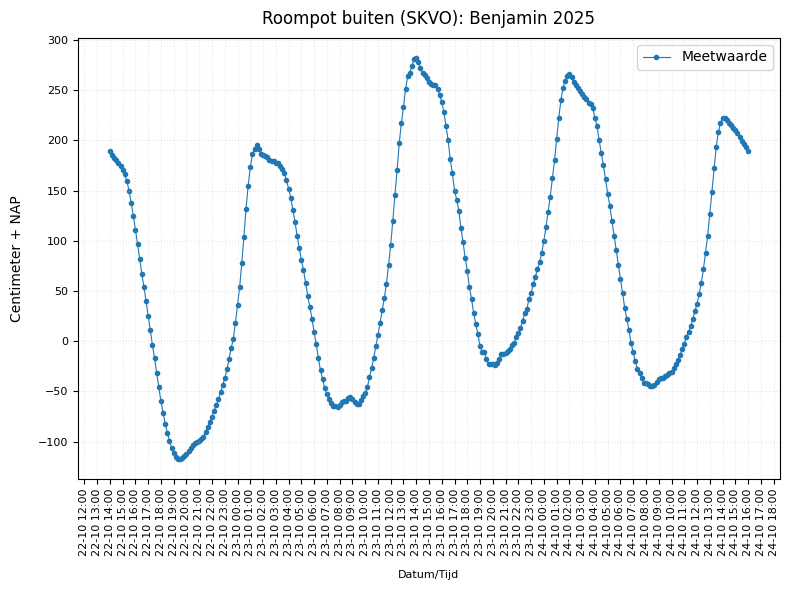

In [8]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(df["tijd"], df["waarde"], linewidth=0.8, marker="o", markersize=3, label="Meetwaarde", zorder=1)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m %H:%M'))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))

ax.set_title("Roompot buiten (SKVO): Benjamin 2025", pad = 10)
ax.set_xlabel("Datum/Tijd", fontsize=8, labelpad=10)
ax.set_ylabel("Centimeter + NAP", labelpad=10)
ax.tick_params(axis="x", rotation=90)
ax.tick_params(axis="both", labelsize=8)
ax.grid(axis="both", alpha=0.3, linestyle=":", zorder=0)
ax.legend()

plt.tight_layout()
plt.show()

In [9]:
max_id = df["waarde"].idxmax()
max_val = df[["tijd","waarde"]].iloc[max_id]
max_val

tijd      2025-10-23 15:00:00+01:00
waarde                        282.0
Name: 144, dtype: object